# End-to-End Machine Learning Project (Regression)

**Dataset:** Global Data on Sustainable Energy  
**Target:** `Value_co2_emissions_kt_by_country` (continuous)

This notebook follows the structure of the provided end-to-end template and adapts each step to the energy/CO2 dataset.


In [220]:
import sys

assert sys.version_info >= (3, 7)

In [221]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

## Setup

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from joblib import dump

plt.style.use("seaborn-v0_8")


# Get the Data

We are predicting a country’s annual CO2 emissions (in kilotons) from its energy mix, economic indicators, and population density.

## Download the Data

In [223]:
from pathlib import Path

DATA_PATH = Path("global-data-on-sustainable-energy.csv")
energy = pd.read_csv(DATA_PATH)

# Drop rows with missing target values (cannot train on missing labels)
before_rows = len(energy)
energy = energy.dropna(subset=["Value_co2_emissions_kt_by_country"])
removed_rows = before_rows - len(energy)

print(f"Rows removed due to missing target: {removed_rows}")
energy.shape


Rows removed due to missing target: 428


(3221, 21)

## Take a Quick Look at the Data Structure

In [224]:
energy.head()


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [225]:
energy.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3221 entries, 0 to 3647
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3221 non-null   object 
 1   Year                                                              3221 non-null   int64  
 2   Access to electricity (% of population)                           3212 non-null   float64
 3   Access to clean fuels for cooking                                 3093 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2358 non-null   float64
 5   Financial flows to developing countries (US $)                    1465 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3201 non-null   float64
 7   Electricity from fossil fuels (TWh)   

In [226]:
energy.describe()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3221.000000,3212.000000,3093.000000,2358.000000,1.465000e+03,3201.000000,3201.000000,3101.000000,3201.000000,3184.000000,3221.000000,3196.000000,3.221000e+03,1380.000000,3126.000000,3157.000000,3.221000e+03,3221.000000,3221.000000
mean,2009.510711,78.008545,62.172082,110.046043,9.127538e+07,33.878747,73.287017,14.458668,24.414180,37.617045,26433.841959,5.461837,1.598665e+05,11.931035,3.861703,12948.225043,6.521633e+05,17.965981,16.639866
std,5.751880,30.960935,39.334393,242.953356,2.968412e+08,30.155060,355.265465,75.855153,102.133196,34.321938,35936.269051,3.591119,7.736611e+05,15.176092,5.309454,19331.385782,1.634789e+06,24.732457,66.810307
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.030000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,56.591630,21.700000,3.850000,2.700000e+05,7.230000,0.300000,0.000000,0.060000,3.975259,2951.367200,3.290000,2.020000e+03,1.860341,1.725870,1290.380508,2.805100e+04,1.650801,-9.429499
50%,2010.000000,97.900000,81.500000,30.115000,5.620000e+06,25.580000,3.100000,0.000000,1.590000,30.187931,13342.630000,4.450000,1.050000e+04,5.970023,3.789156,4413.062005,1.184840e+05,17.060816,19.503304
75%,2014.000000,100.000000,100.000000,110.500000,5.261000e+07,56.820000,27.770000,0.000000,9.450000,64.707375,34507.516000,6.170000,6.058000e+04,17.063990,5.954249,15174.278430,5.131200e+05,39.399872,46.869107
max,2019.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5098.220000,809.410000,2014.570000,100.000010,262585.700000,32.570000,1.070722e+07,83.540470,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


In [227]:
energy["Value_co2_emissions_kt_by_country"].value_counts().head(10)

Value_co2_emissions_kt_by_country
10.000000     18
170.000002    15
180.000007    14
59.999999     12
70.000000     12
119.999997    11
319.999993     9
400.000006     9
500.000000     9
129.999995     9
Name: count, dtype: int64

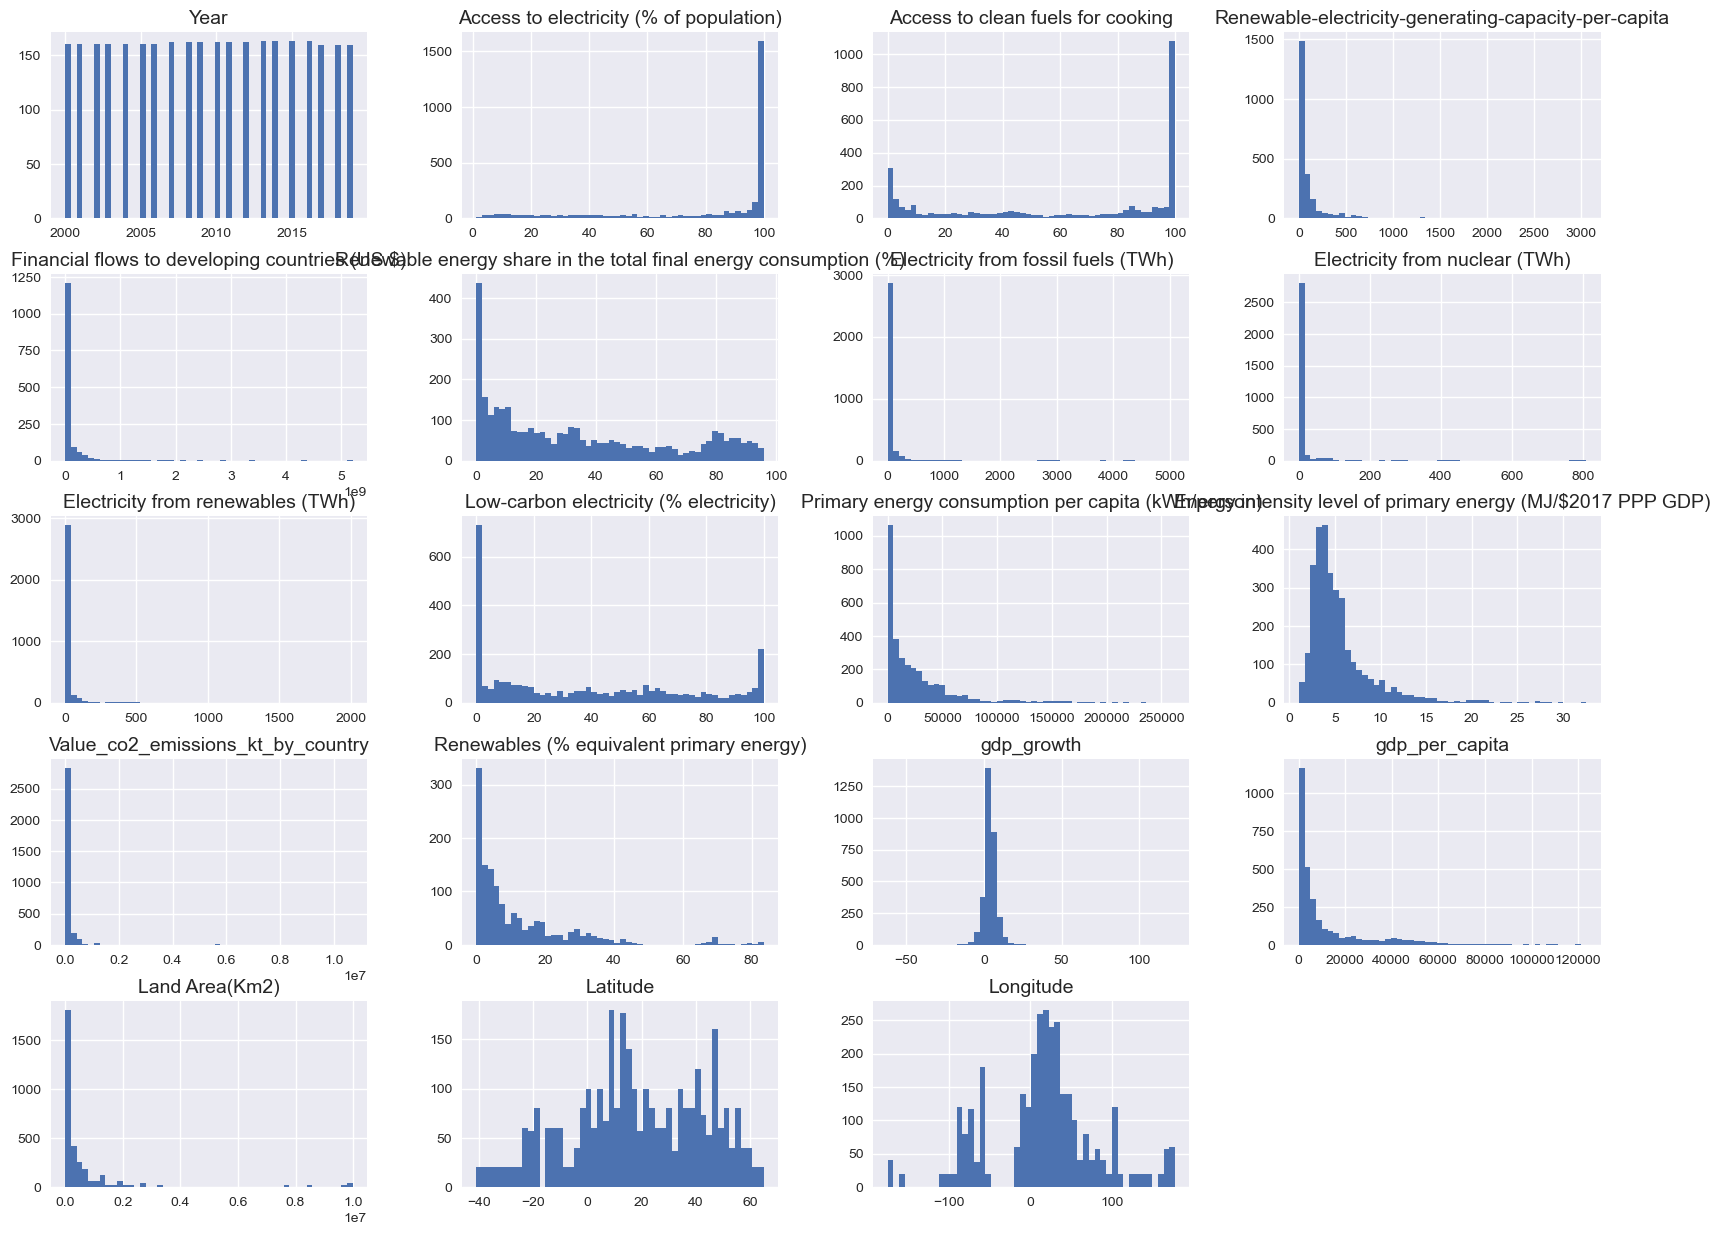

In [228]:

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

energy.hist(bins=50, figsize=(20, 15))
plt.show()


## Create a Test Set

In [229]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]


In [230]:
train_set, test_set = shuffle_and_split_data(energy, 0.2)
len(train_set)

2577

### Stable Test Set Using an Identifier

To keep a consistent test set across dataset updates, we can split using a stable identifier hash.


In [231]:
from zlib import crc32

# Keep rows in the test set stable across updates
# Use a stable identifier built from Entity + Year
energy_with_id = energy.copy()
energy_with_id["id"] = (
    energy_with_id["Entity"].astype(str) + "_" + energy_with_id["Year"].astype(str)
)

# Hash-based split functions

def is_id_in_test_set(identifier, test_ratio):
    identifier_bytes = str(identifier).encode("utf-8")
    return crc32(identifier_bytes) & 0xffffffff < test_ratio * 2**32


def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column].astype(str)
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

hash_train_set, hash_test_set = split_data_with_id_hash(energy_with_id, 0.2, "id")
len(hash_train_set), len(hash_test_set)


(2598, 623)

## Stratified Sampling (Using CO2 Emissions)

We create quantile-based bins of CO2 emissions to ensure the train/test split preserves the target distribution.


In [232]:
# Create a stratification category based on CO2 emissions
energy["co2_cat"] = pd.qcut(
    energy["Value_co2_emissions_kt_by_country"],
    q=5,
    labels=False,
    duplicates="drop"
)

strat_train_set, strat_test_set = train_test_split(
    energy, test_size=0.2, random_state=42, stratify=energy["co2_cat"]
)

for set_ in (strat_train_set, strat_test_set):
    set_.drop("co2_cat", axis=1, inplace=True)


In [233]:
len(test_set)

644

In [234]:
energy = strat_train_set.copy()

# Discover and Visualize the Data to Gain Insights

## Visualizing Geographical Data

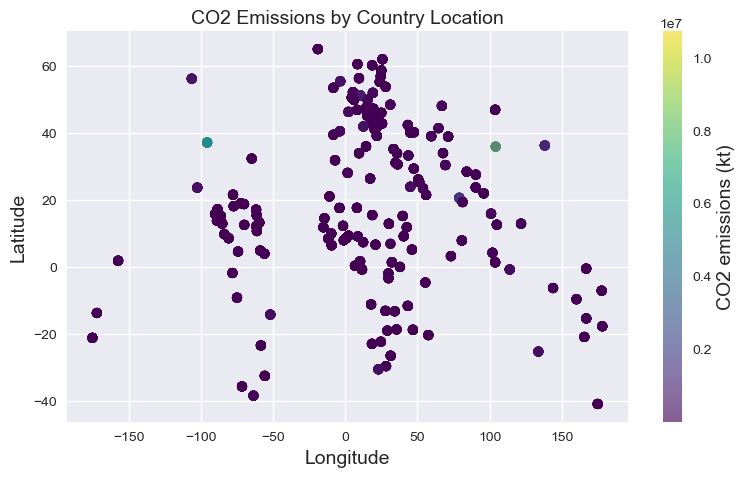

In [235]:
plt.figure(figsize=(8, 5))
plt.scatter(
    energy["Longitude"],
    energy["Latitude"],
    c=energy["Value_co2_emissions_kt_by_country"],
    cmap="viridis",
    alpha=0.6
)
plt.colorbar(label="CO2 emissions (kt)")
plt.title("CO2 Emissions by Country Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()


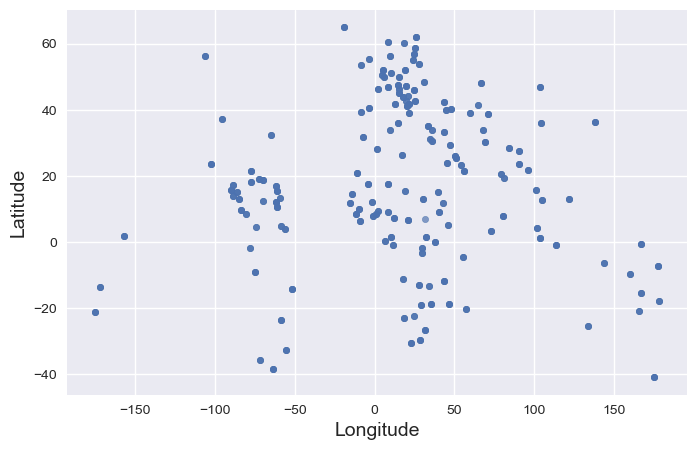

In [236]:
energy.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    grid=True,
    alpha=0.2,
    figsize=(8, 5)
)
plt.show()


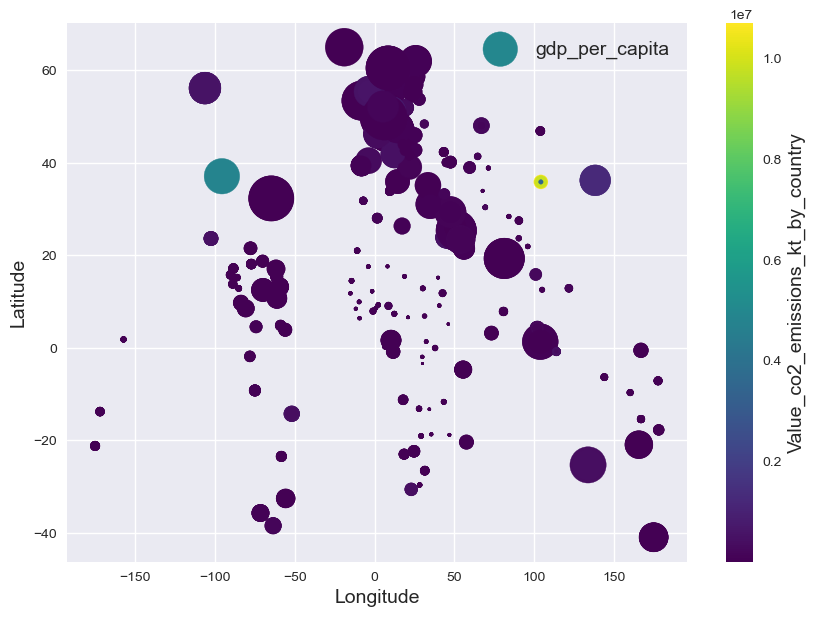

In [237]:
energy.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    grid=True,
    s=energy["gdp_per_capita"] / 100,  
    label="gdp_per_capita",
    c="Value_co2_emissions_kt_by_country",
    cmap="viridis",
    colorbar=True,
    legend=True,
    sharex=False,
    figsize=(10, 7)
)
plt.show()

## Looking for Correlations

In [238]:
corr = energy.select_dtypes(include=["number"]).corr()

corr["Value_co2_emissions_kt_by_country"].sort_values(ascending=False).head(10)


Value_co2_emissions_kt_by_country                 1.000000
Electricity from fossil fuels (TWh)               0.989058
Electricity from renewables (TWh)                 0.835026
Land Area(Km2)                                    0.648185
Electricity from nuclear (TWh)                    0.591364
Financial flows to developing countries (US $)    0.160576
Access to electricity (% of population)           0.127310
Latitude                                          0.113273
Access to clean fuels for cooking                 0.094446
gdp_per_capita                                    0.092683
Name: Value_co2_emissions_kt_by_country, dtype: float64

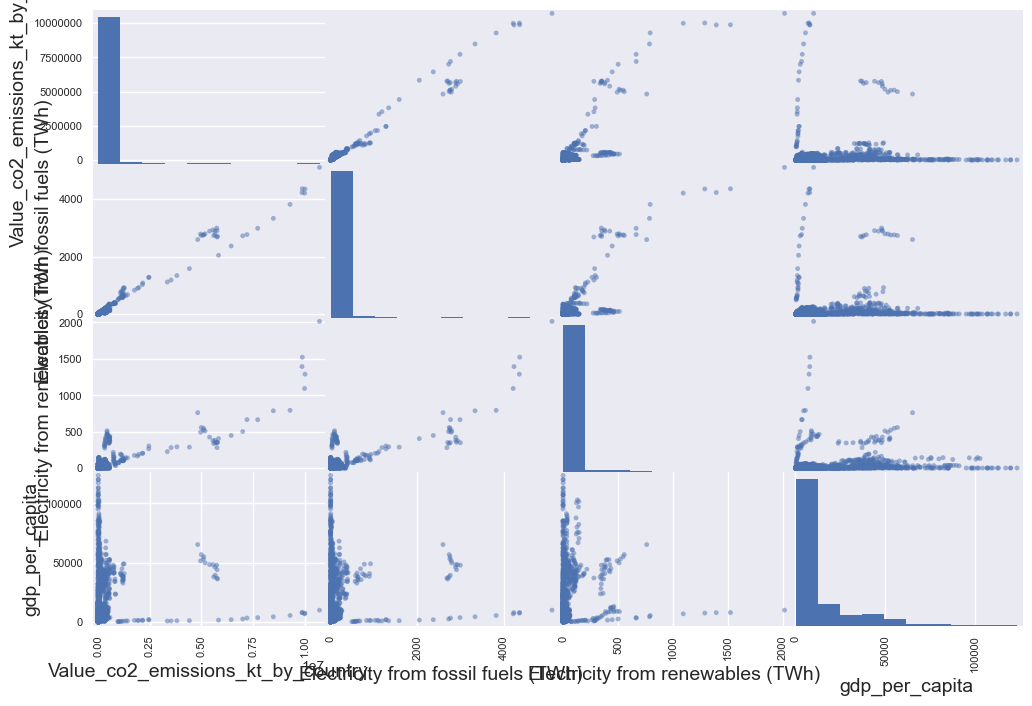

In [239]:
from pandas.plotting import scatter_matrix

density_col = [c for c in energy.columns if "Density" in c][0]

attributes = [
    "Value_co2_emissions_kt_by_country",
    "Electricity from fossil fuels (TWh)",
    "Electricity from renewables (TWh)",
    "gdp_per_capita",
    density_col
]

scatter_matrix(energy[attributes], figsize=(12, 8))
plt.show()



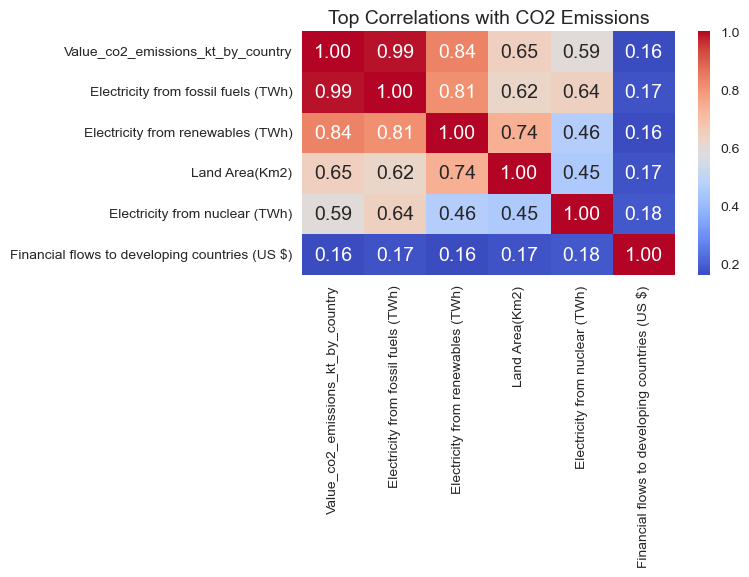

In [240]:
plt.figure(figsize=(8, 6))
strong = corr["Value_co2_emissions_kt_by_country"].abs().sort_values(ascending=False).head(6).index
sns.heatmap(corr.loc[strong, strong], annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top Correlations with CO2 Emissions")
plt.tight_layout()


## Experimenting with Attribute Combinations

In [241]:
energy = energy.copy()
energy["TotalElectricity_TWh"] = (
    energy["Electricity from fossil fuels (TWh)"]
    + energy["Electricity from nuclear (TWh)"]
    + energy["Electricity from renewables (TWh)"]
)
energy["FossilShare"] = (
    energy["Electricity from fossil fuels (TWh)"]
    / energy["TotalElectricity_TWh"].replace(0, np.nan)
)

energy[["TotalElectricity_TWh", "FossilShare", "Value_co2_emissions_kt_by_country"]].corr().iloc[:, 2]


TotalElectricity_TWh                 0.976683
FossilShare                          0.053988
Value_co2_emissions_kt_by_country    1.000000
Name: Value_co2_emissions_kt_by_country, dtype: float64

# Prepare the Data for Machine Learning Algorithms

## Data Cleaning

In [242]:
missing = energy.isna().mean().sort_values(ascending=False)
missing.head(10)


Renewables (% equivalent primary energy)                0.569099
Financial flows to developing countries (US $)          0.546972
Renewable-electricity-generating-capacity-per-capita    0.270575
FossilShare                                             0.043866
TotalElectricity_TWh                                    0.038432
Electricity from nuclear (TWh)                          0.038432
Access to clean fuels for cooking                       0.037267
gdp_growth                                              0.026398
gdp_per_capita                                          0.017081
Low-carbon electricity (% electricity)                  0.012422
dtype: float64

In [243]:
energy = strat_train_set.drop("Value_co2_emissions_kt_by_country", axis=1)
energy_labels = strat_train_set["Value_co2_emissions_kt_by_country"].copy()


In [244]:
null_rows_idx = energy.isnull().any(axis=1)
energy.loc[null_rows_idx].head()


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
3514,United States,2012,100.000000,100.0,NaN,NaN,8.73,2779.02,769.33,492.32,31.223783,79102.340,5.15,6.886334,2.249546,51602.931050,36,9833517.0,37.090240,-95.712891
3118,Spain,2015,100.000000,100.0,NaN,NaN,16.33,123.19,57.20,97.09,55.604000,33920.240,2.85,17.507902,3.835173,25732.018360,94,505370.0,40.463667,-3.749220
2341,Netherlands,2016,100.000000,100.0,NaN,NaN,5.59,95.09,3.96,14.78,16.463146,60943.150,3.38,4.676411,2.191714,46007.852920,508,41543.0,52.132633,5.291266
1373,Guatemala,2007,80.719406,37.1,82.97,NaN,63.36,4.44,0.00,4.58,50.776050,4454.024,4.20,NaN,6.337719,2490.749127,167,108889.0,15.783471,-90.230759
405,Bermuda,2006,100.000000,NaN,NaN,NaN,0.44,0.00,0.00,0.00,NaN,50145.137,1.56,NaN,5.543866,95221.858870,1281,54.0,32.299507,-64.790337


## Handling Text and Categorical Attributes

In [245]:
energy_cat = energy[["Entity"]]
energy_cat.head(8)

,Entity
3514,United States
3118,Spain
2341,Netherlands
1373,Guatemala
405,Bermuda
2498,Oman
2515,Pakistan
750,Colombia


In [246]:
ordinal_encoder.categories_

[array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
        'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
        'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh',
        'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda',
        'Bhutan', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
        'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
        'Canada', 'Cayman Islands', 'Central African Republic', 'Chad',
        'Chile', 'China', 'Colombia', 'Comoros', 'Costa Rica', 'Croatia',
        'Cuba', 'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica',
        'Dominican Republic', 'Ecuador', 'El Salvador',
        'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia',
        'Fiji', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany',
        'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea',
        'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary',
        'Iceland', 'India', 'Indonesia', 'Iraq', 'Irelan

In [247]:
from sklearn.preprocessing import OneHotEncoder

energy_cat = energy[["Entity"]].fillna("Unknown")
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
energy_cat_1hot = cat_encoder.fit_transform(energy_cat)
energy_cat_1hot[:5]


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [248]:
cat_encoder.categories_

[array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
        'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
        'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh',
        'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda',
        'Bhutan', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
        'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
        'Canada', 'Cayman Islands', 'Central African Republic', 'Chad',
        'Chile', 'China', 'Colombia', 'Comoros', 'Costa Rica', 'Croatia',
        'Cuba', 'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica',
        'Dominican Republic', 'Ecuador', 'El Salvador',
        'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia',
        'Fiji', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany',
        'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea',
        'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary',
        'Iceland', 'India', 'Indonesia', 'Iraq', 'Irelan

In [249]:
train_set = strat_train_set.copy()
test_set = strat_test_set.copy()

X_train = train_set.drop(columns=["Value_co2_emissions_kt_by_country"])
y_train = train_set["Value_co2_emissions_kt_by_country"]

X_test = test_set.drop(columns=["Value_co2_emissions_kt_by_country"])
y_test = test_set["Value_co2_emissions_kt_by_country"]

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

num_cols[:5], cat_cols

# Include engineered features in numeric columns
num_cols = list(num_cols) + ["TotalElectricity_TWh", "FossilShare"]


## Feature Scaling

Scaling helps models that are sensitive to feature magnitude (e.g., linear models). We scale numeric features after imputation while leaving one‑hot encoded categories as 0/1

In [250]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
energy_num = energy.select_dtypes(include=[np.number])
energy_num_min_max_scaled = min_max_scaler.fit_transform(energy_num)


In [251]:
from sklearn.preprocessing import StandardScaler

energy_num = energy.select_dtypes(include=[np.number])
std_scaler = StandardScaler()
energy_num_std_scaled = std_scaler.fit_transform(energy_num)


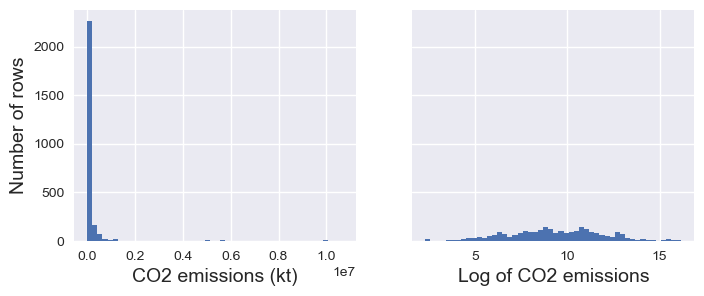

In [252]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
strat_train_set["Value_co2_emissions_kt_by_country"].hist(ax=axs[0], bins=50)
strat_train_set["Value_co2_emissions_kt_by_country"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("CO2 emissions (kt)")
axs[1].set_xlabel("Log of CO2 emissions")
axs[0].set_ylabel("Number of rows")
plt.show()



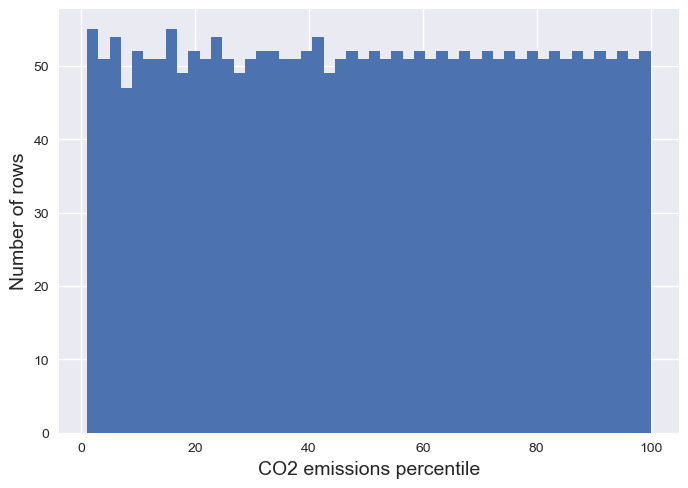

In [253]:
percentiles = [np.percentile(strat_train_set["Value_co2_emissions_kt_by_country"], p)
               for p in range(1, 100)]
flattened_co2 = pd.cut(
    strat_train_set["Value_co2_emissions_kt_by_country"],
    bins=[-np.inf] + percentiles + [np.inf],
    labels=range(1, 100 + 1)
)

flattened_co2.hist(bins=50)
plt.xlabel("CO2 emissions percentile")
plt.ylabel("Number of rows")
plt.show()


In [254]:
from sklearn.metrics.pairwise import rbf_kernel

gdp_series = energy[["gdp_per_capita"]].dropna()
gdp_simil = rbf_kernel(gdp_series, [[20000]], gamma=0.00005)


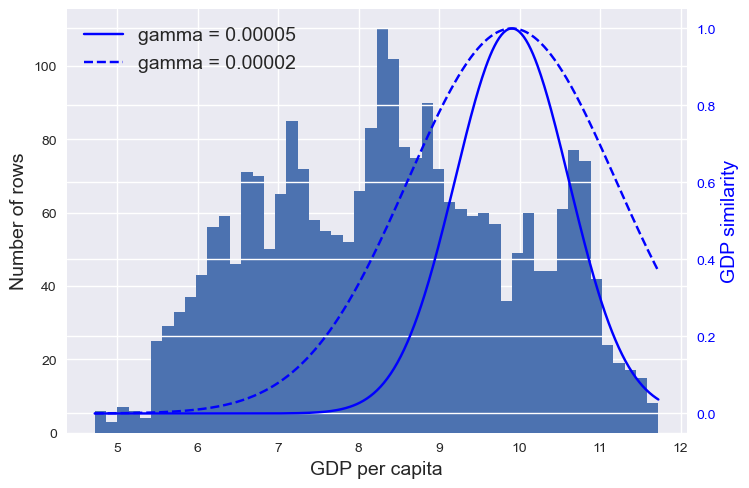

In [255]:
from sklearn.metrics.pairwise import rbf_kernel

gdp = np.log(energy["gdp_per_capita"].dropna())

values = np.linspace(gdp.min(), gdp.max(), 500).reshape(-1, 1)
rbf1 = rbf_kernel(values, [[np.log(20000)]], gamma=1.0)
rbf2 = rbf_kernel(values, [[np.log(20000)]], gamma=0.3)


fig, ax1 = plt.subplots()

ax1.set_xlabel("GDP per capita")
ax1.set_ylabel("Number of rows")
ax1.hist(gdp, bins=50)

ax2 = ax1.twinx()
color = "blue"
ax2.plot(values, rbf1, color=color, label="gamma = 0.00005")
ax2.plot(values, rbf2, color=color, label="gamma = 0.00002", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("GDP similarity", color=color)

plt.legend(loc="upper left")
plt.show()




In [256]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# X = feature, y = target
X = energy[["gdp_per_capita"]]
y = energy_labels  # from strat_train_set

mask = X["gdp_per_capita"].notna()
X = X.loc[mask]
y = y.loc[mask]

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(y.to_frame())

model = LinearRegression()
model.fit(X, scaled_labels)

some_new_data = X.iloc[:5]  
scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)
predictions


array([[298459.31955608],
       [204593.27454066],
       [278158.99764984],
       [120268.22384837],
       [456719.53601373]])

In [257]:
predictions

array([[298459.31955608],
       [204593.27454066],
       [278158.99764984],
       [120268.22384837],
       [456719.53601373]])

In [258]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression

X = energy[["gdp_per_capita"]]
y = energy_labels  # from strat_train_set

mask = X["gdp_per_capita"].notna()
X = X.loc[mask]
y = y.loc[mask]

model = TransformedTargetRegressor(
    regressor=LinearRegression(),
    transformer=StandardScaler()
)
model.fit(X, y)

some_new_data = X.iloc[:5]
predictions = model.predict(some_new_data)
predictions


array([298459.31955608, 204593.27454066, 278158.99764984, 120268.22384837,
       456719.53601373])

In [259]:
predictions

array([298459.31955608, 204593.27454066, 278158.99764984, 120268.22384837,
       456719.53601373])

In [260]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)


## Custom Transformers

In [261]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_co2 = log_transformer.transform(
    strat_train_set[["Value_co2_emissions_kt_by_country"]]
)


In [262]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np

gdp = energy[["gdp_per_capita"]].dropna()
gdp_log = np.log(gdp)

rbf_transformer = FunctionTransformer(
    rbf_kernel,
    kw_args=dict(Y=[[np.log(20000.0)]], gamma=1.0)
)
gdp_simil = rbf_transformer.transform(gdp_log)
gdp_simil[:5]



array([[0.40721563],
       [0.93846857],
       [0.49956278],
       [0.01304293],
       [0.08758993]])

In [263]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics.pairwise import rbf_kernel

mtl_coords = [45.5017, -73.5673]  # Montreal
geo_transformer = FunctionTransformer(
    rbf_kernel,
    kw_args=dict(Y=[mtl_coords], gamma=0.1)
)

geo_simil = geo_transformer.transform(energy[["Latitude", "Longitude"]])


In [264]:
geo_simil

array([[4.24882009e-025],
       [1.57777822e-213],
       [1.03964041e-272],
       ...,
       [1.03964041e-272],
       [0.00000000e+000],
       [4.24882009e-025]])

In [265]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(
    energy[["Electricity from fossil fuels (TWh)", "Electricity from renewables (TWh)"]]
    .replace(0, np.nan)
    .dropna()
    .to_numpy()
)


array([[ 5.64474326],
       [ 1.26882274],
       [ 6.43369418],
       ...,
       [ 0.01960784],
       [12.28063241],
       [ 3.40213734]])

In [266]:
class EnergyFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self,
                 fossil_col="Electricity from fossil fuels (TWh)",
                 nuclear_col="Electricity from nuclear (TWh)",
                 renew_col="Electricity from renewables (TWh)"):
        self.fossil_col = fossil_col
        self.nuclear_col = nuclear_col
        self.renew_col = renew_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if not all(col in X.columns for col in [self.fossil_col, self.nuclear_col, self.renew_col]):
            missing = [col for col in [self.fossil_col, self.nuclear_col, self.renew_col] if col not in X.columns]
            raise ValueError(f"Missing columns for feature engineering: {missing}")
        total = X[self.fossil_col] + X[self.nuclear_col] + X[self.renew_col]
        X["TotalElectricity_TWh"] = total
        X["FossilShare"] = X[self.fossil_col] / total.replace(0, np.nan)
        return X


In [267]:
lin_model.fit(X_train, y_train)
train_preds = lin_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f"Linear Regression RMSE (train): {train_rmse:,.2f}")




Linear Regression RMSE (train): 33,449.25


In [268]:
from sklearn.cluster import KMeans

class ClusterLabeler(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=8, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X)
        return self

    def transform(self, X):
        return self.kmeans_.predict(X).reshape(-1, 1)

geo_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("cluster", ClusterLabeler(n_clusters=8, random_state=42)),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)


In [269]:
from sklearn.preprocessing import StandardScaler

geo = energy[["Latitude", "Longitude"]].dropna()
geo_scaled = StandardScaler().fit_transform(geo)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
similarities = cluster_simil.fit_transform(geo_scaled)




In [270]:
similarities[:3].round(2)

array([[0.  , 0.47, 0.02, 0.  , 0.05, 0.  , 0.  , 0.  , 0.02, 0.01],
       [0.17, 0.12, 0.18, 0.  , 0.81, 0.  , 0.  , 0.03, 0.63, 0.  ],
       [0.17, 0.03, 0.04, 0.  , 0.98, 0.  , 0.  , 0.01, 0.41, 0.  ]])

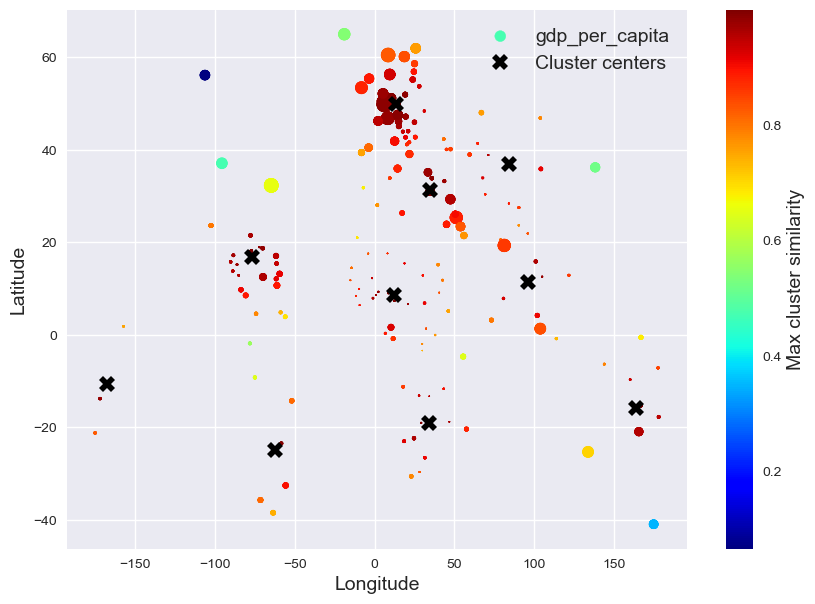

In [271]:
from sklearn.preprocessing import StandardScaler

# Base data for plotting
plot_df = energy[["Latitude", "Longitude", "gdp_per_capita"]].dropna(subset=["Latitude", "Longitude"]).copy()

# Fit cluster similarity on scaled geo coordinates
scaler = StandardScaler()
geo_scaled = scaler.fit_transform(plot_df[["Latitude", "Longitude"]])

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
similarities = cluster_simil.fit_transform(geo_scaled)

plot_df["Max cluster similarity"] = similarities.max(axis=1)

# Size for markers (avoid NaNs)
sizes = plot_df["gdp_per_capita"].fillna(plot_df["gdp_per_capita"].median())

plot_df.plot(
    kind="scatter", x="Longitude", y="Latitude", grid=True,
    s=sizes / 1000, label="gdp_per_capita",
    c="Max cluster similarity", cmap="jet", colorbar=True,
    legend=True, sharex=False, figsize=(10, 7)
)

# Plot cluster centers back in original coordinates
centers = scaler.inverse_transform(cluster_simil.kmeans_.cluster_centers_)
plt.plot(centers[:, 1], centers[:, 0], linestyle="", color="black",
         marker="X", markersize=12, label="Cluster centers")
plt.legend(loc="upper right")
plt.show()


## Transformation Pipelines

In [272]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


In [273]:


full_preprocess = Pipeline(
    steps=[
        ("feature_adder", EnergyFeatureAdder()),
        ("preprocess", preprocessor)
    ]
)


In [283]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

energy_num = energy.select_dtypes(include=[np.number])
energy_num_prepared = num_pipeline.fit_transform(energy_num)

df_energy_num_prepared = pd.DataFrame(
    energy_num_prepared,
    columns=num_pipeline.get_feature_names_out(),
    index=energy_num.index
)

df_energy_num_prepared.head()


,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
3514,0.428388,0.708581,0.962300,-0.276140,-0.229132,-0.842282,7.951025,10.421096,4.914453,-0.192992,1.440625,-0.086754,-0.154399,-0.312773,2.020972,5.623791,0.772362,-1.691581
3118,0.952131,0.708581,0.962300,-0.276140,-0.229132,-0.590474,0.154069,0.603604,0.769473,0.518879,0.200990,-0.736772,0.860554,-0.001930,0.674143,-0.089791,0.908518,-0.311940
2341,1.126712,0.708581,0.962300,-0.276140,-0.229132,-0.946318,0.071574,-0.130368,-0.093754,-0.623984,0.942402,-0.586985,-0.365570,-0.324110,1.729695,-0.373890,1.379495,-0.176315
1373,-0.444517,0.085758,-0.660406,-0.025279,-0.229132,0.967755,-0.194555,-0.184961,-0.200727,0.377909,-0.607457,-0.355240,-0.249292,0.488665,-0.535789,-0.332640,-0.087611,-1.609338
405,-0.619098,0.708581,0.466975,-0.276140,-0.229132,-1.116952,-0.207590,-0.184961,-0.248760,-0.194812,0.646143,-1.101346,-0.249292,0.333040,4.291757,-0.399302,0.579001,-1.227680


In [284]:
num_pipeline.steps

[('imputer', SimpleImputer(strategy='median')),
 ('standardize', StandardScaler())]

In [285]:
num_pipeline[1]

StandardScaler()

In [286]:
num_pipeline[:-1]

Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

In [289]:
numeric_transformer.named_steps["imputer"]


SimpleImputer(strategy='median')

In [294]:
num_pipeline.set_params(imputer__strategy="median")



Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('standardize', StandardScaler())])

In [296]:
from sklearn.pipeline import make_pipeline

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])


In [298]:
# Normalize column names
energy.columns = energy.columns.str.strip().str.replace("\n", " ", regex=False)

# Find the density column
density_col = [c for c in energy.columns if "Density" in c][0]

# Convert to numeric
energy[density_col] = pd.to_numeric(energy[density_col], errors="coerce")


In [307]:
X = strat_train_set.drop(columns=["Value_co2_emissions_kt_by_country"])
energy_prepared = full_preprocess.fit_transform(X)


In [317]:
def safe_ratio(X):
    num = X[:, [0]]
    denom = X[:, [1]]
    return np.divide(num, denom, out=np.zeros_like(num), where=denom != 0)

def safe_log(X):
    return np.log1p(np.clip(X, a_min=0, a_max=None))

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(safe_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(safe_log, feature_names_out="one-to-one"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

geo_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
)

preprocessing = ColumnTransformer(
    transformers=[
        ("fossil_vs_renew", ratio_pipeline(),
         ["Electricity from fossil fuels (TWh)", "Electricity from renewables (TWh)"]),
        ("log", log_pipeline,
         ["Electricity from fossil fuels (TWh)", "Electricity from renewables (TWh)",
          "Electricity from nuclear (TWh)", "Financial flows to developing countries (US $)",
          "gdp_per_capita"]),
        ("geo", geo_pipeline, ["Latitude", "Longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
)


In [318]:
X = strat_train_set.drop(columns=["Value_co2_emissions_kt_by_country"])
energy_prepared = preprocessing.fit_transform(X)
energy_prepared.shape



(2576, 306)

In [322]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"cluster_sim_{i}" for i in range(self.n_clusters)]





In [327]:
preprocessing = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)





In [330]:
full_preprocess.fit(X)
full_preprocess.named_steps["preprocess"].get_feature_names_out()



array(['num__Year', 'num__Access to electricity (% of population)',
       'num__Access to clean fuels for cooking',
       'num__Renewable-electricity-generating-capacity-per-capita',
       'num__Financial flows to developing countries (US $)',
       'num__Renewable energy share in the total final energy consumption (%)',
       'num__Electricity from fossil fuels (TWh)',
       'num__Electricity from nuclear (TWh)',
       'num__Electricity from renewables (TWh)',
       'num__Low-carbon electricity (% electricity)',
       'num__Primary energy consumption per capita (kWh/person)',
       'num__Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'num__Renewables (% equivalent primary energy)', 'num__gdp_growth',
       'num__gdp_per_capita', 'num__Land Area(Km2)', 'num__Latitude',
       'num__Longitude', 'num__TotalElectricity_TWh', 'num__FossilShare',
       'cat__Entity_Afghanistan', 'cat__Entity_Albania',
       'cat__Entity_Algeria', 'cat__Entity_Angola',
    

# Select and Train a Model

## Training and Evaluating on the Training Set

In [331]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

X = strat_train_set.drop(columns=["Value_co2_emissions_kt_by_country"])
y = strat_train_set["Value_co2_emissions_kt_by_country"]

lin_reg = make_pipeline(full_preprocess, LinearRegression())
lin_reg.fit(X, y)


Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('feature_adder', EnergyFeatureAdder()),
                                 ('preprocess',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['Year',
                                                                    'Access to '
                                                                    'electricity '
                                                                    '(% of '
                                                                    'population)',
                                                                    'Access to '
                                                                    'clean '
                                                                    'fuels for '
                                                                    'cooking',
                                                                    'Renewable-electricity-generating-c...
                                                                    'primary '
                                                                    'energy)',
                                                                    'gdp_growth',
                                                                    'gdp_per_capita',
                                                                    'Land '
                                                                    'Area(Km2)',
                                                                    'Latitude',
                                                                    'Longitude',
                                                                    'TotalElectricity_TWh',
                                                                    'FossilShare']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   Index(['Entity', 'Density\n(P/Km2)'], dtype='object'))]))])),
                ('linearregression', LinearRegression())])

In [332]:
energy_predictions = lin_reg.predict(X)
energy_predictions[:5].round(-2)


array([5.2984e+06, 2.3390e+05, 1.6740e+05, 1.5900e+04, 3.1000e+03])

In [333]:
y.iloc[:5].values


array([4.95606006e+06, 2.56279999e+05, 1.58539993e+05, 1.24099999e+04,
       6.52726000e+02])

In [334]:
error_ratios = energy_predictions[:5].round(-2) / y.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))


6.9%, -8.7%, 5.6%, 28.1%, 374.9%


In [335]:
from sklearn.metrics import mean_squared_error
import numpy as np

lin_rmse = np.sqrt(mean_squared_error(y, energy_predictions))
lin_rmse


np.float64(33035.200140199115)

In [336]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

X = strat_train_set.drop(columns=["Value_co2_emissions_kt_by_country"])
y = strat_train_set["Value_co2_emissions_kt_by_country"]

tree_reg = make_pipeline(full_preprocess, DecisionTreeRegressor(random_state=42))
tree_reg.fit(X, y)



Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('feature_adder', EnergyFeatureAdder()),
                                 ('preprocess',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['Year',
                                                                    'Access to '
                                                                    'electricity '
                                                                    '(% of '
                                                                    'population)',
                                                                    'Access to '
                                                                    'clean '
                                                                    'fuels for '
                                                                    'cooking',
                                                                    'Renewable-electricity-generating-c...
                                                                    'gdp_growth',
                                                                    'gdp_per_capita',
                                                                    'Land '
                                                                    'Area(Km2)',
                                                                    'Latitude',
                                                                    'Longitude',
                                                                    'TotalElectricity_TWh',
                                                                    'FossilShare']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   Index(['Entity', 'Density\n(P/Km2)'], dtype='object'))]))])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [337]:
energy_predictions = tree_reg.predict(X)
tree_rmse = np.sqrt(mean_squared_error(y, energy_predictions))
tree_rmse


np.float64(5.476475146237628e-07)

In [338]:
lin_model = Pipeline(
    steps=[
        ("preprocess", full_preprocess),
        ("model", LinearRegression())
    ]
)

lin_model.fit(X_train, y_train)
train_preds = lin_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f"Linear Regression RMSE (train): {train_rmse:,.2f}")


Linear Regression RMSE (train): 33,035.20


## Better Evaluation Using Cross-Validation

In [341]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(
    tree_reg,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print(f"Linear Regression CV RMSE: {cv_scores.mean():,.2f} ± {cv_scores.std():,.2f}")



Linear Regression CV RMSE: 38,327.98 ± 7,394.27


In [340]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     56362.848653
std      24232.670879
min      20978.091844
25%      38917.499061
50%      55119.627097
75%      68262.982321
max      93497.415994
dtype: float64

In [342]:
lin_rmses = -cross_val_score(
    lin_reg,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)
pd.Series(lin_rmses).describe()



count       10.000000
mean     37708.756220
std      11847.465617
min      24957.632518
25%      28182.855389
50%      35293.456058
75%      43727.977596
max      60677.418419
dtype: float64

In [343]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(full_preprocess, RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(
    forest_reg,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)


In [344]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     60972.704331
std      24842.263570
min      14008.597431
25%      48241.673815
50%      67342.664161
75%      76960.512518
max      95251.885610
dtype: float64

In [345]:
forest_reg.fit(X, y)
energy_predictions = forest_reg.predict(X)
forest_rmse = np.sqrt(mean_squared_error(y, energy_predictions))
forest_rmse


np.float64(22805.143617713664)

# Fine-Tune Your Model

## Grid Search

In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocess", full_preprocess),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
grid_search.best_params_


{'model__max_depth': 20,
 'model__min_samples_leaf': 1,
 'model__n_estimators': 200}

Exception ignored in: <function ResourceTracker.__del__ at 0x105075bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108e85bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103295bc0>
Traceback (most recent call last

In [349]:
print(str(full_preprocess.get_params().keys())[:1000] + "...")


dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'feature_adder', 'preprocess', 'feature_adder__fossil_col', 'feature_adder__nuclear_col', 'feature_adder__renew_col', 'preprocess__force_int_remainder_cols', 'preprocess__n_jobs', 'preprocess__remainder', 'preprocess__sparse_threshold', 'preprocess__transformer_weights', 'preprocess__transformers', 'preprocess__verbose', 'preprocess__verbose_feature_names_out', 'preprocess__num', 'preprocess__cat', 'preprocess__num__memory', 'preprocess__num__steps', 'preprocess__num__transform_input', 'preprocess__num__verbose', 'preprocess__num__imputer', 'preprocess__num__scaler', 'preprocess__num__imputer__add_indicator', 'preprocess__num__imputer__copy', 'preprocess__num__imputer__fill_value', 'preprocess__num__imputer__keep_empty_features', 'preprocess__num__imputer__missing_values', 'preprocess__num__imputer__strategy', 'preprocess__num__scaler__copy', 'preprocess__num__scaler__with_mean', 'preprocess__num__scaler__with_std', 'preproces

In [350]:
grid_search.best_params_

{'model__max_depth': 20,
 'model__min_samples_leaf': 1,
 'model__n_estimators': 200}

In [351]:
grid_search.best_estimator_

Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('feature_adder', EnergyFeatureAdder()),
                                 ('preprocess',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['Year',
                                                                    'Access to '
                                                                    'electricity '
                                                                    '(% of '
                                                                    'population)',
                                                                    'Access to '
                                                                    'clean '
                                                                    'fuels for '
                                                                    'cooking',
                                                                    'Renewable-electricity-generating...
                                                                    'gdp_per_capita',
                                                                    'Land '
                                                                    'Area(Km2)',
                                                                    'Latitude',
                                                                    'Longitude',
                                                                    'TotalElectricity_TWh',
                                                                    'FossilShare']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   Index(['Entity', 'Density\n(P/Km2)'], dtype='object'))]))])),
                ('model',
                 RandomForestRegressor(max_depth=20, n_estimators=200,
                                       random_state=42))])

In [352]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "split0_test_score",
        "split1_test_score",
        "split2_test_score",
        "mean_test_score",
    ]
]

score_cols = ["split0_test_score", "split1_test_score", "split2_test_score", "mean_test_score"]
cv_res[score_cols] = -cv_res[score_cols]  # converts neg RMSE to RMSE

cv_res.rename(
    columns={
        "param_model__n_estimators": "n_estimators",
        "param_model__max_depth": "max_depth",
        "param_model__min_samples_leaf": "min_samples_leaf",
        "split0_test_score": "split0_rmse",
        "split1_test_score": "split1_rmse",
        "split2_test_score": "split2_rmse",
        "mean_test_score": "mean_rmse",
    },
    inplace=True,
)

cv_res.head()


,n_estimators,max_depth,min_samples_leaf,split0_rmse,split1_rmse,split2_rmse,mean_rmse
4,200,20,1,102909.846084,43019.399171,88922.949078,78284.064778
0,200,None,1,106743.924690,44608.668076,87341.406662,79564.666476
5,300,20,1,103245.358478,45463.796810,90003.241557,79570.798949
1,300,None,1,108044.499471,45454.770424,89132.891439,80877.387112
2,200,None,2,90704.729808,53537.445646,98472.568853,80904.914769


## Randomized Search

In [354]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": randint(5, 40),
    "model__min_samples_leaf": randint(1, 5),
}

rnd_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rnd_search.fit(X_train, y_train)



RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              Pipeline(steps=[('feature_adder',
                                                               EnergyFeatureAdder()),
                                                              ('preprocess',
                                                               ColumnTransformer(transformers=[('num',
                                                                                                Pipeline(steps=[('imputer',
                                                                                                                 SimpleImputer(strategy='median')),
                                                                                                                ('scaler',
                                                                                                                 StandardScaler())]),
                                                                                                ['Year',
                                                                                                 'Access '
                                                                                                 'to '
                                                                                                 'electricity '
                                                                                                 '(% '
                                                                                                 'of '
                                                                                                 'population)',
                                                                                                 'Access '
                                                                                                 'to '
                                                                                                 'clean '
                                                                                                 'fuels '
                                                                                                 'for '
                                                                                                 '...
                   param_distributions={'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x3181a6d50>,
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x3181a5590>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x30b4b5d30>},
                   random_state=42, scoring='neg_root_mean_squared_error')

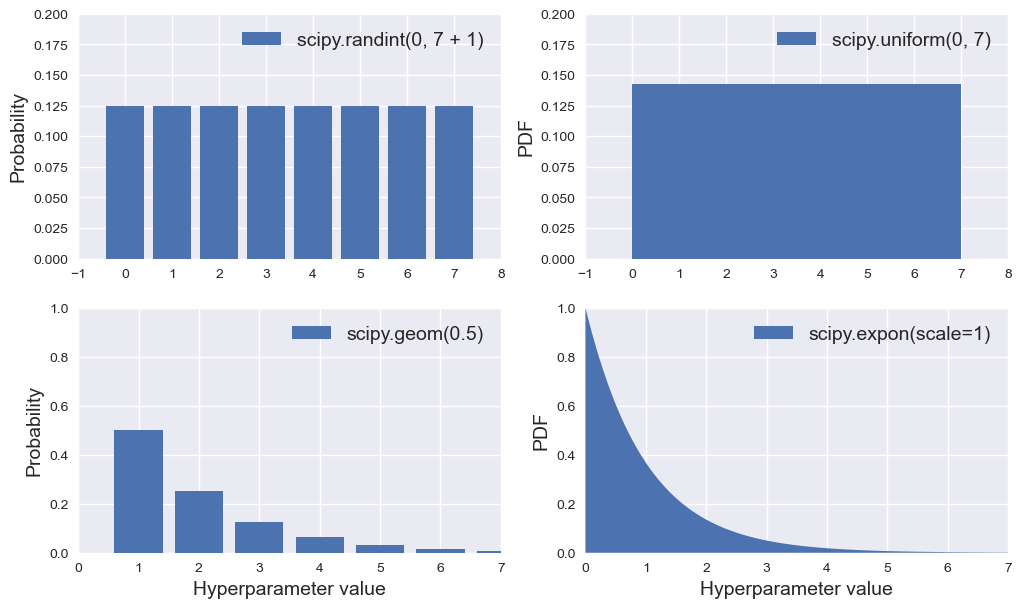

In [356]:
from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

## Analyze the Best Models and Their Errors

In [360]:

rnd_search.fit(X_train, y_train)
final_model = rnd_search.best_estimator_
feature_importances = final_model["model"].feature_importances_
feature_importances.round(2)




array([0.  , 0.  , 0.  , 0.04, 0.  , 0.  , 0.62, 0.  , 0.01, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.31, 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.

In [361]:
feature_names = final_model["preprocess"].named_steps["preprocess"].get_feature_names_out()
sorted(zip(feature_importances, feature_names), reverse=True)


[(np.float64(0.624646513337139), 'num__Electricity from fossil fuels (TWh)'),
 (np.float64(0.3083520634878516), 'num__TotalElectricity_TWh'),
 (np.float64(0.04305056001238838),
  'num__Renewable-electricity-generating-capacity-per-capita'),
 (np.float64(0.009702715322952795), 'num__Electricity from renewables (TWh)'),
 (np.float64(0.002132011611340221),
  'num__Renewable energy share in the total final energy consumption (%)'),
 (np.float64(0.002095754640348289),
  'num__Renewables (% equivalent primary energy)'),
 (np.float64(0.0017723479816541883),
  'num__Financial flows to developing countries (US $)'),
 (np.float64(0.0010994127508235636),
  'num__Energy intensity level of primary energy (MJ/$2017 PPP GDP)'),
 (np.float64(0.000818634444718213), 'num__gdp_per_capita'),
 (np.float64(0.0007185087844667528), 'num__Electricity from nuclear (TWh)'),
 (np.float64(0.0006919722054730201), 'num__FossilShare'),
 (np.float64(0.0006184440037914181),
  'num__Primary energy consumption per capita

## Evaluate Your System on the Test Set

In [362]:
X_test = strat_test_set.drop(columns=["Value_co2_emissions_kt_by_country"])
y_test = strat_test_set["Value_co2_emissions_kt_by_country"].copy()

final_predictions = final_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(final_rmse)



44139.30523053812


In [364]:
from scipy import stats
import numpy as np

mse = mean_squared_error(y_test, final_predictions)
m = len(y_test)
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2

ci = np.sqrt(stats.t.interval(
    confidence, m - 1,
    loc=squared_errors.mean(),
    scale=stats.sem(squared_errors)
))
print(ci)

#We can compute a 95% confidence interval for the test RMSE:

[22479.53794904 58234.24169736]


## Model persistence using joblib

In [367]:



import joblib

joblib.dump(final_model, "my_co2_emissions_model.pkl")


['my_co2_emissions_model.pkl']

In [368]:
import joblib

# Save the trained model
joblib.dump(final_model, "co2_emissions_model.pkl")

# Reload the model
final_model_reloaded = joblib.load("co2_emissions_model.pkl")

# Predict on new data (features only)
new_data = strat_test_set.drop(columns=["Value_co2_emissions_kt_by_country"]).iloc[:5]
predictions = final_model_reloaded.predict(new_data)
predictions


array([ 3500.91540394,  6200.00002548, 48016.89872557,   177.2784843 ,
        4766.96199836])

In [ ]:
predictions

array([ 3500.91540394,  6200.00002548, 48016.89872557,   177.2784843 ,
        4766.96199836])

Exception ignored in: <function ResourceTracker.__del__ at 0x109229bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102d8dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106c4dbc0>
Traceback (most recent call last